# Implied Volatility, Volatility Skew and Surface

## Objectives

This notebook studies the implied-volatility structure embedded in option prices.

The main objectives are:

1. recover implied volatility from Black-Scholes option prices;
2. construct a synthetic option market with strike-dependent volatility;
3. examine the volatility smile/skew across strikes;
4. quantify the pricing error generated by a constant-volatility Black-Scholes model;
5. construct an implied-volatility surface across strikes and maturities;
6. motivate the use of stochastic-volatility models.

The analysis uses synthetic option prices so that the underlying volatility structure is known exactly. This allows the numerical implied-volatility solver to be validated before applying it to real market data.

In [1]:
import sys
from pathlib import Path

project_root = Path(
    "/Users/amber/derivatives-pricing-calibration"
).resolve()

assert (project_root / "src").exists(), (
    f"Cannot find src folder under {project_root}"
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)

print("Project root:", project_root)
print("Python executable:", sys.executable)

Project root: /Users/amber/derivatives-pricing-calibration
Python executable: /Users/amber/derivatives-pricing-calibration/.venv/bin/python


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.black_scholes import (
    call_price,
)

from src.volatility.implied_volatility import (
    implied_volatility,
)

## 1. Implied Volatility

In the Black-Scholes model, the option price is written as

$$
V_{\mathrm{BS}}
=
V(S,K,T,r,\sigma).
$$

If the option market price is observed, volatility can instead be treated as the unknown parameter.

The implied volatility $\sigma_{\mathrm{imp}}$ is defined implicitly by

$$
V_{\mathrm{BS}}
\left(
S,K,T,r,\sigma_{\mathrm{imp}}
\right)
=
V_{\mathrm{market}}.
$$

Equivalently, define the root-finding problem

$$
f(\sigma)
=
V_{\mathrm{BS}}(\sigma)
-
V_{\mathrm{market}}.
$$

The implied volatility satisfies

$$
f(\sigma_{\mathrm{imp}})=0.
$$

Unlike the Black-Scholes pricing formula, there is no simple closed-form expression for implied volatility. Therefore, numerical root-finding is required.

In this project, Brent's method is used to solve the nonlinear equation.

For standard European calls and puts, Black-Scholes prices increase with volatility because

$$
\mathrm{Vega}
=
\frac{\partial V}{\partial \sigma}
>
0.
$$

This monotonicity makes implied-volatility inversion numerically well behaved for valid option prices.

In [5]:
S0 = 100.0
K = 100.0
T = 1.0
r = 0.05

sigma_true = 0.25

market_price = call_price(
    S0,
    K,
    T,
    r,
    sigma_true,
)

sigma_recovered = implied_volatility(
    market_price,
    S0,
    K,
    T,
    r,
    option_type="call",
)

print("Synthetic market price:", market_price)
print("True volatility:", sigma_true)
print("Recovered implied volatility:", sigma_recovered)
print(
    "Absolute recovery error:",
    abs(sigma_recovered - sigma_true),
)

Synthetic market price: 12.335998930368717
True volatility: 0.25
Recovered implied volatility: 0.24999999999982564
Absolute recovery error: 1.7436052601738083e-13


## 2. From Constant Volatility to Volatility Skew

The Black-Scholes model assumes that volatility is constant for all options written on the same underlying asset.

Under this assumption,

$$
\sigma(K,T)=\sigma,
$$

so volatility does not depend on either strike or maturity.

If Black-Scholes were an exact description of market prices, options with different strikes and maturities would produce approximately the same implied volatility.

In practice, option markets often display systematic variation in implied volatility across strikes and maturities.

This produces structures commonly referred to as:

- volatility smile;
- volatility skew or smirk;
- volatility term structure;
- implied-volatility surface.

To study this effect in a controlled environment, a synthetic volatility structure is constructed below.

In [6]:
def synthetic_market_volatility(
    strike,
    maturity,
    spot=100.0,
):
    """
    Synthetic implied-volatility structure.

    The function introduces:
    - a downward volatility skew;
    - mild curvature;
    - a maturity effect.
    """

    log_moneyness = np.log(
        np.asarray(strike) / spot
    )

    volatility = (
        0.20
        - 0.12 * log_moneyness
        + 0.25 * log_moneyness**2
        + 0.015 * np.exp(-maturity)
    )

    return volatility

In [7]:
S0 = 100.0
T = 1.0
r = 0.05

strikes = np.arange(
    70.0,
    135.0,
    5.0,
)

true_ivs = synthetic_market_volatility(
    strikes,
    T,
    S0,
)

market_prices = np.array([
    call_price(
        S0,
        K,
        T,
        r,
        sigma,
    )
    for K, sigma in zip(
        strikes,
        true_ivs,
    )
])

recovered_ivs = np.array([
    implied_volatility(
        price,
        S0,
        K,
        T,
        r,
        option_type="call",
    )
    for K, price in zip(
        strikes,
        market_prices,
    )
])

iv_results = pd.DataFrame({
    "Strike": strikes,
    "True IV": true_ivs,
    "Recovered IV": recovered_ivs,
    "Recovery Error": np.abs(
        recovered_ivs - true_ivs
    ),
    "Market Price": market_prices,
})

iv_results

,Strike,True IV,Recovered IV,Recovery Error,Market Price
0,70.0,0.280123,0.280123,7.571721e-14,34.155791
1,75.0,0.260730,0.260730,2.131628e-14,29.664909
2,80.0,0.244744,0.244744,3.130690e-12,25.313841
3,85.0,0.231624,0.231624,2.552875e-12,21.162545
4,90.0,0.220937,0.220937,3.885781e-16,17.284389
5,95.0,0.212331,0.212331,4.423545e-12,13.758703
6,100.0,0.205518,0.205518,4.147738e-12,10.657793
7,105.0,0.200258,0.200258,8.246265e-12,8.031607
8,110.0,0.196352,0.196352,2.517958e-12,5.895770
9,115.0,0.193630,0.193630,7.637058e-12,4.228209


In [8]:
max_recovery_error = np.max(
    np.abs(
        recovered_ivs - true_ivs
    )
)

mean_recovery_error = np.mean(
    np.abs(
        recovered_ivs - true_ivs
    )
)

print(
    "Maximum IV recovery error:",
    max_recovery_error,
)

print(
    "Mean IV recovery error:",
    mean_recovery_error,
)

Maximum IV recovery error: 2.9377750232484345e-11
Mean IV recovery error: 5.485360029448079e-12


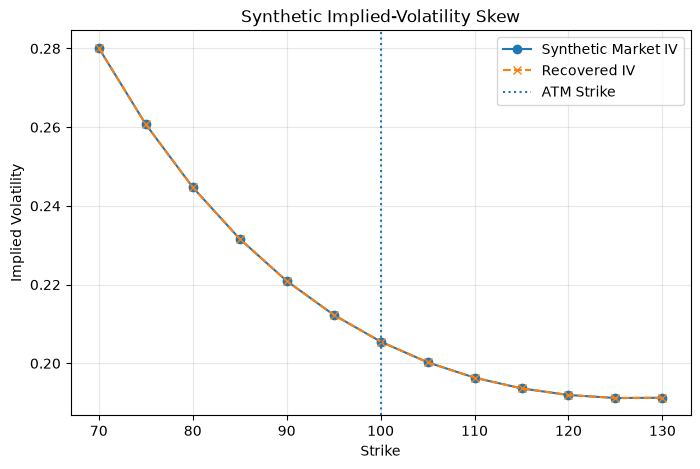

In [9]:
plt.figure(
    figsize=(8, 5),
)

plt.plot(
    strikes,
    true_ivs,
    marker="o",
    label="Synthetic Market IV",
)

plt.plot(
    strikes,
    recovered_ivs,
    linestyle="--",
    marker="x",
    label="Recovered IV",
)

plt.axvline(
    S0,
    linestyle=":",
    label="ATM Strike",
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title(
    "Synthetic Implied-Volatility Skew"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "implied_vol_smile.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3. Testing the Constant-Volatility Assumption

A constant-volatility Black-Scholes benchmark is now constructed.

Rather than choosing an arbitrary volatility, the model is calibrated to the at-the-money option.

The ATM implied volatility is therefore used as the single constant volatility parameter:

$$
\sigma_{\mathrm{constant}}
=
\sigma_{\mathrm{imp}}(K=S_0).
$$

This volatility is then applied to every strike.

If the constant-volatility assumption were adequate, the resulting Black-Scholes prices should remain close to the synthetic market prices across the strike range.

The resulting cross-sectional pricing errors therefore provide a direct diagnostic of the constant-volatility assumption.

In [10]:
atm_index = np.argmin(
    np.abs(strikes - S0)
)

constant_sigma = recovered_ivs[
    atm_index
]

constant_vol_prices = np.array([
    call_price(
        S0,
        K,
        T,
        r,
        constant_sigma,
    )
    for K in strikes
])

pricing_errors = (
    constant_vol_prices
    - market_prices
)

absolute_pricing_errors = np.abs(
    pricing_errors
)

constant_vol_results = pd.DataFrame({
    "Strike": strikes,
    "Market Price": market_prices,
    "Constant-Vol BS Price": (
        constant_vol_prices
    ),
    "Pricing Error": pricing_errors,
    "Absolute Error": (
        absolute_pricing_errors
    ),
})

print(
    "ATM constant volatility:",
    constant_sigma,
)

constant_vol_results

ATM constant volatility: 0.2055181916134239


,Strike,Market Price,Constant-Vol BS Price,Pricing Error,Absolute Error
0,70.0,34.155791,33.564013,-5.917780e-01,5.917780e-01
1,75.0,29.664909,29.020592,-6.443175e-01,6.443175e-01
2,80.0,25.313841,24.665937,-6.479043e-01,6.479043e-01
3,85.0,21.162545,20.582983,-5.795610e-01,5.795610e-01
4,90.0,17.284389,16.850536,-4.338523e-01,4.338523e-01
5,95.0,13.758703,13.530235,-2.284673e-01,2.284673e-01
6,100.0,10.657793,10.657793,-1.558647e-10,1.558647e-10
7,105.0,8.031607,8.240231,2.086247e-01,2.086247e-01
8,110.0,5.895770,6.258596,3.628269e-01,3.628269e-01
9,115.0,4.228209,4.674262,4.460536e-01,4.460536e-01


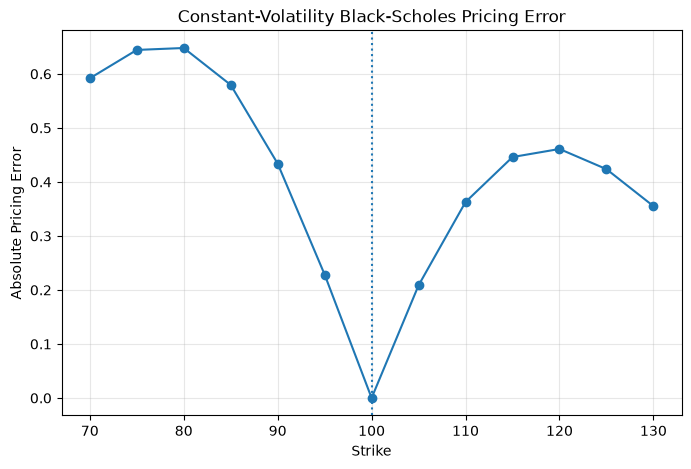

In [11]:
plt.figure(
    figsize=(8, 5),
)

plt.plot(
    strikes,
    absolute_pricing_errors,
    marker="o",
)

plt.axvline(
    S0,
    linestyle=":",
)

plt.xlabel("Strike")
plt.ylabel(
    "Absolute Pricing Error"
)

plt.title(
    "Constant-Volatility Black-Scholes Pricing Error"
)

plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "constant_vol_pricing_error.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [12]:
constant_vol_mae = np.mean(
    absolute_pricing_errors
)

constant_vol_rmse = np.sqrt(
    np.mean(
        pricing_errors**2
    )
)

max_pricing_error = np.max(
    absolute_pricing_errors
)

print(
    "Constant-volatility MAE:",
    constant_vol_mae,
)

print(
    "Constant-volatility RMSE:",
    constant_vol_rmse,
)

print(
    "Maximum absolute pricing error:",
    max_pricing_error,
)

Constant-volatility MAE: 0.414085538363409
Constant-volatility RMSE: 0.45180314041919956
Maximum absolute pricing error: 0.6479043126232398


## 4. Implied-Volatility Surface

Strike dependence alone does not fully describe the option market.

Implied volatility may also vary with maturity.

The resulting function

$$
\sigma_{\mathrm{imp}}
=
\sigma_{\mathrm{imp}}(K,T)
$$

is known as the implied-volatility surface.

A synthetic surface is constructed below by generating option prices across multiple strikes and maturities and then independently recovering the implied volatility of every option.

In [13]:
surface_strikes = np.arange(
    80.0,
    125.0,
    5.0,
)

maturities = np.array([
    0.25,
    0.50,
    1.00,
    1.50,
    2.00,
])

surface_rows = []

for maturity in maturities:

    for strike in surface_strikes:

        true_sigma = (
            synthetic_market_volatility(
                strike,
                maturity,
                S0,
            )
        )

        market_price = call_price(
            S0,
            strike,
            maturity,
            r,
            true_sigma,
        )

        recovered_sigma = (
            implied_volatility(
                market_price,
                S0,
                strike,
                maturity,
                r,
                option_type="call",
            )
        )

        surface_rows.append({
            "Strike": strike,
            "Maturity": maturity,
            "True IV": true_sigma,
            "Recovered IV": (
                recovered_sigma
            ),
            "Recovery Error": abs(
                recovered_sigma
                - true_sigma
            ),
        })

surface_results = pd.DataFrame(
    surface_rows
)

surface_results.head(10)

,Strike,Maturity,True IV,Recovered IV,Recovery Error
0,80.0,0.25,0.250907,0.250907,2.997602e-15
1,85.0,0.25,0.237787,0.237787,7.771561e-16
2,90.0,0.25,0.227100,0.227100,2.486900e-14
3,95.0,0.25,0.218495,0.218495,8.326673e-17
4,100.0,0.25,0.211682,0.211682,1.149847e-11
5,105.0,0.25,0.206422,0.206422,2.400577e-11
6,110.0,0.25,0.202516,0.202516,1.110223e-16
7,115.0,0.25,0.199794,0.199794,1.609823e-15
8,120.0,0.25,0.198114,0.198114,5.057066e-14
9,80.0,0.50,0.248323,0.248323,2.832093e-11


In [14]:
surface_max_error = (
    surface_results[
        "Recovery Error"
    ].max()
)

surface_mean_error = (
    surface_results[
        "Recovery Error"
    ].mean()
)

print(
    "Maximum surface recovery error:",
    surface_max_error,
)

print(
    "Mean surface recovery error:",
    surface_mean_error,
)

Maximum surface recovery error: 2.9377750232484345e-11
Mean surface recovery error: 3.801585589534461e-12


In [15]:
strike_grid, maturity_grid = (
    np.meshgrid(
        surface_strikes,
        maturities,
    )
)

iv_surface = np.empty_like(
    strike_grid,
    dtype=float,
)

for i, maturity in enumerate(
    maturities
):
    for j, strike in enumerate(
        surface_strikes
    ):

        row = surface_results[
            (
                surface_results[
                    "Strike"
                ] == strike
            )
            &
            (
                surface_results[
                    "Maturity"
                ] == maturity
            )
        ]

        iv_surface[i, j] = row[
            "Recovered IV"
        ].iloc[0]

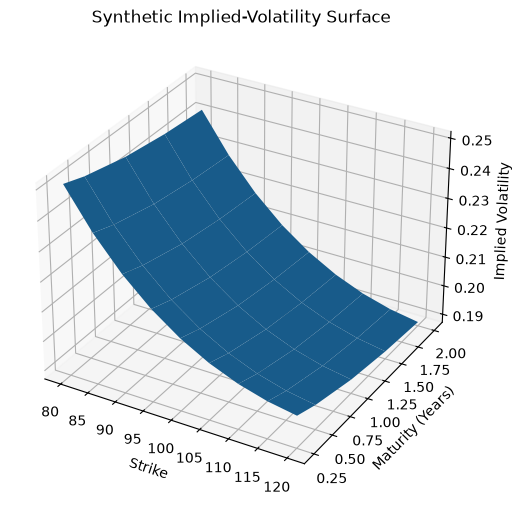

In [16]:
fig = plt.figure(
    figsize=(9, 6),
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

ax.plot_surface(
    strike_grid,
    maturity_grid,
    iv_surface,
)

ax.set_xlabel("Strike")
ax.set_ylabel(
    "Maturity (Years)"
)
ax.set_zlabel(
    "Implied Volatility"
)

ax.set_title(
    "Synthetic Implied-Volatility Surface"
)

plt.savefig(
    figure_dir / "implied_vol_surface.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Interpretation

The numerical experiments reveal three important results.

First, the implied-volatility solver accurately recovers the volatility values used to generate the synthetic option prices. The recovery errors are close to numerical precision, providing direct validation of the inversion procedure.

Second, implied volatility varies systematically across strikes. The resulting downward skew means that a single constant volatility cannot reproduce the entire cross-section of option prices.

When the Black-Scholes model is calibrated using the ATM implied volatility and this volatility is subsequently applied to all strikes, systematic pricing errors appear away from the calibration point.

This illustrates an important distinction between model calibration and model fit.

A model may fit one option exactly while failing to explain other options simultaneously.

Third, allowing both strike and maturity to vary produces an implied-volatility surface

$$
\sigma_{\mathrm{imp}}(K,T),
$$

demonstrating that the volatility structure can contain both cross-sectional and maturity-dependent variation.

These results do not imply that the Black-Scholes model is useless. Its closed-form solution remains an important analytical benchmark and provides the standard convention through which market option prices are translated into implied volatility.

Rather, the results demonstrate the limitation of the constant-volatility assumption when attempting to explain an entire option surface.

## 6. Motivation for Stochastic Volatility

The Black-Scholes framework assumes

$$
\sigma_t=\sigma,
$$

where volatility is constant.

The implied-volatility experiments show that a single constant value cannot generally reproduce a non-flat volatility surface.

A natural extension is therefore to allow volatility itself to evolve dynamically over time.

Stochastic-volatility models introduce an additional random process for variance.

One important example is the Heston model, in which the asset price and variance evolve jointly.

The implied-volatility analysis developed here therefore provides the empirical and numerical motivation for introducing stochastic volatility and, subsequently, calibrating richer models to an option surface.

## Conclusion

This experiment implemented and validated a numerical Black-Scholes implied-volatility solver using Brent's root-finding method.

Synthetic option prices generated from known volatility structures were inverted successfully, with implied-volatility recovery errors close to numerical precision.

The strike-based experiment produced a non-flat implied-volatility skew. When a constant-volatility Black-Scholes model was calibrated to the ATM option and applied across all strikes, systematic pricing errors emerged away from the calibration point.

Extending the experiment across both strike and maturity produced a complete synthetic implied-volatility surface.

The results highlight the distinction between using Black-Scholes as a pricing benchmark and using a single constant volatility to explain an entire option market.

Black-Scholes remains valuable as an analytical benchmark and as the standard mapping between option prices and implied volatility. However, a non-flat implied-volatility surface motivates richer models in which volatility can vary dynamically.

This provides the foundation for subsequent analysis of stochastic-volatility models and market calibration.